In [1]:
import torch
import numpy as np
from torch import Tensor

from src.models import mk_model
from src.plotting import plt_sample
from src.dataset import load_preprocessed_dataset
from src.configs import TrainingConfig, ModelConfig

In [2]:
x_train, y_train, x_test = load_preprocessed_dataset()

target label: 1


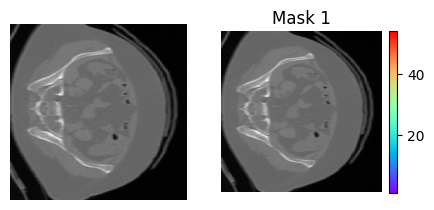

[0 1]


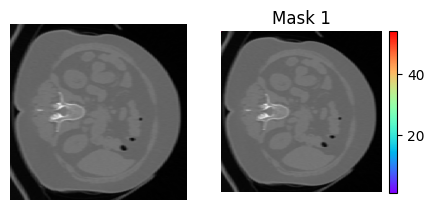

[0 1]


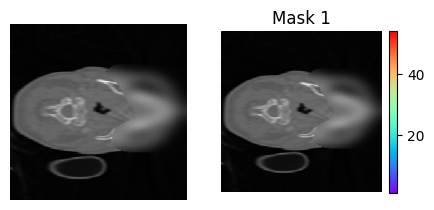

[0 1]


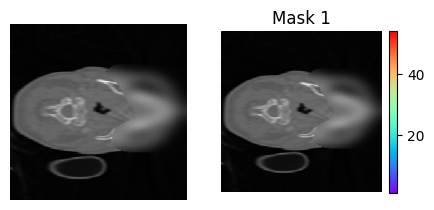

[0 1]
target label: 2


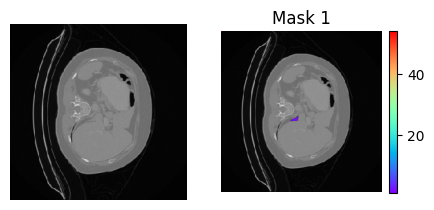

[0 2]


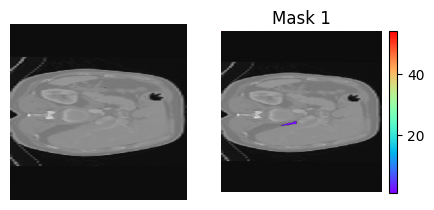

[0 2]


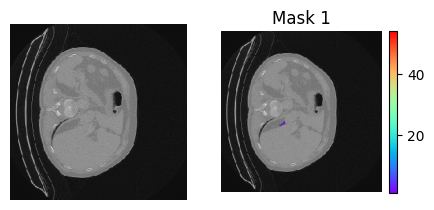

[0 2]


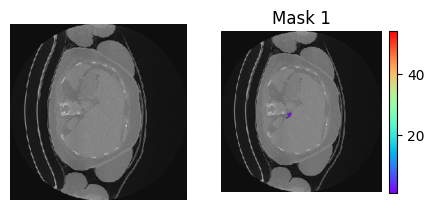

[0 2]
target label: 3


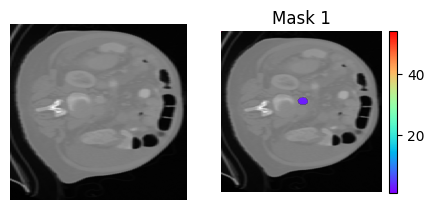

[0 3]


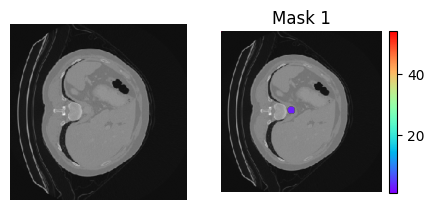

[0 3]


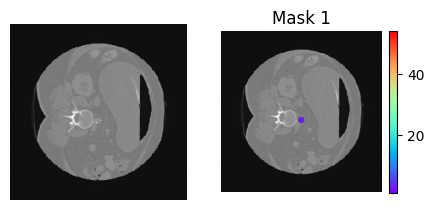

[0 3]


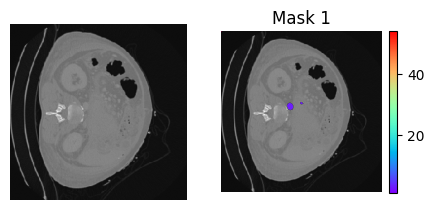

[0 3]
target label: 6


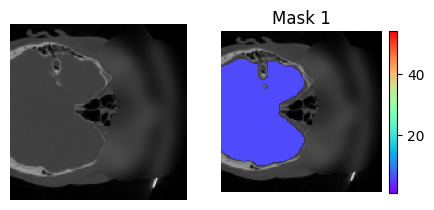

[0 6]


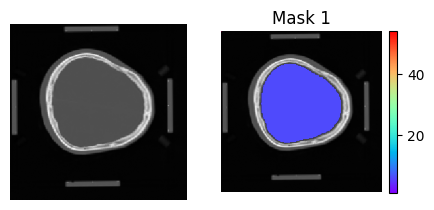

[0 6]


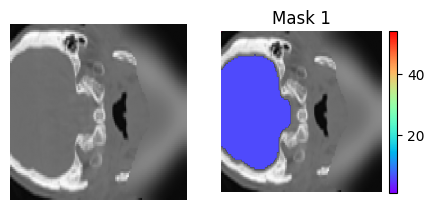

[0 6]


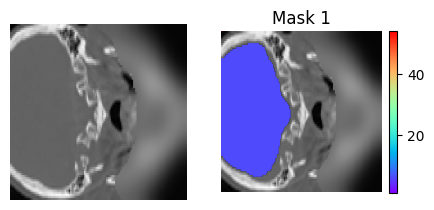

[0 6]


In [ ]:
import matplotlib.pyplot as plt

def plt_sample(slice_image: Tensor, seg_masks: Tensor):
    fig, axes = plt.subplots(
        len(slice_image),
        1 + len(seg_masks), figsize=(5, 5)
    )
    # Show base grayscale image
    axes[0].imshow(slice_image, cmap="gray")
    # axes[0].set_title("Image")
    axes[0].axis("off")

    # Display masks with their colormap + colorbar
    for seg_i, seg_mask in enumerate(seg_masks):
        ax = axes[seg_i + 1]
        ax.imshow(slice_image, cmap="gray")

        seg = seg_mask.reshape((256, 256))
        seg_masked = np.ma.masked_where(seg == 0, seg)

        im = ax.imshow(seg_masked, cmap="rainbow")
        ax.set_title(f"Mask {seg_i + 1}")
        ax.axis("off")

        # Add colorbar for this mask
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

max_y_train = y_train.amax()
for target_label in [1, 2, 3, 6]:
    print("target label:", target_label)
    has_label_mask = (y_train.reshape(-1, 256 * 256) == target_label).any(dim=1)
    x_with_label = x_train[has_label_mask] #[:, 0]
    y_with_label = y_train[has_label_mask]
    y_with_label[y_with_label != target_label] = 0
    for idx in range(5):
        x_sample = x_with_label[idx, 0]
        y_sample = y_with_label[idx] # / max_y_train
        # uniques_in_sample = np.unique(y_sample.cpu().numpy())
        y_sample[0, 0] = max_y_train # to make sure cmap remains consistent
        y_sample[0, 1] = 1 # to make sure cmap remains consistent
        plt_sample(x_sample, y_sample)
        # print(uniques_in_sample)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_cfg, model_cfg = TrainingConfig(), ModelConfig()
model = mk_model(train_cfg, model_cfg).to(device)
b_size = 10
x, y_true = x_train[:b_size], y_train[:b_size]
with torch.no_grad():
    y_pred = model(x.to(device))

In [ ]:
display(y_pred.shape)
display(torch.argmax(y_true.reshape(-1, 256 * 256), dim=1))

In [ ]:
from torch.nn.functional import one_hot

def match_pred_and_true(y_pred: Tensor, y_true: Tensor) -> tuple[Tensor, Tensor]:
    one_hot_pred = one_hot(y_pred.type(torch.long)).permute(0, 3, 1, 2).unsqueeze(1)
    one_hot_true = one_hot(y_true.type(torch.long)).permute(0, 3, 1, 2).unsqueeze(2)
    intersection = one_hot_true == one_hot_pred
    union = one_hot_pred[:, None] == one_hot_true[:, :, None]

match_pred_and_true(y_pred, y_true)